# 08 — M3: Cross-Modal Attention Fusion (Thesis Main Contribution)

**Multimodal fusion** — FAU (camera) + CAN telemetry with bidirectional cross-modal attention.

```
H_fau  = BiLSTM(128, seq)(FAU)      → (B, 240, 256)
H_tele = LSTM(64, seq)(Tele)        → (B, 240, 64)

ctx_f2t = CrossAttn(Q=H_fau,  K=H_tele)  → let FAU attend to Tele
ctx_t2f = CrossAttn(Q=H_tele, K=H_fau )  → let Tele attend to FAU

GAP([ctx_f2t, ctx_t2f, H_fau, H_tele]) → Dense(128) → Dense(3, softmax)
```

The attention weights are interpretable: they show **which CAN timesteps** the facial
features attend to and vice versa.

In [43]:
import sys, warnings, os, importlib
from pathlib import Path
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# ── Robust root detection ─────────────────────────────────────────────────────
_cwd = Path().resolve()
ROOT = _cwd if (_cwd / 'src').exists() else _cwd.parent
assert (ROOT / 'src').exists(), f"Cannot find src/ — ROOT resolved to {ROOT}"

# ── Fix sys.path ──────────────────────────────────────────────────────────────
_src = str(ROOT / 'src')
_nb  = str(ROOT / 'notebooks')
sys.path = [p for p in sys.path if Path(p).resolve() != Path(_nb).resolve()]
if _src in sys.path:
    sys.path.remove(_src)
sys.path.insert(0, _src)

# Clear stale module cache
_stale = [m for m in sys.modules if m.split('.')[0] in
          ('models', 'utils', 'data', 'inference', 'src')]
for _m in _stale:
    del sys.modules[_m]
importlib.invalidate_caches()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

from models.architecture import build_model, M3FusionModel
from models.train         import cross_validate
from utils.helpers        import (
    plot_training_history,
    plot_confusion_matrix,
    plot_fold_results,
    plot_attention_weights,
)
from data.load_data import load_fold

FOLD_DIR = ROOT / 'datasets' / 'processed' / 'ul_dd'

# ── Checkpoint directory — check both possible locations ──────────────────────
_ckpt_candidates = [
    ROOT / 'notebooks' / 'models' / 'checkpoints',   # saved by earlier runs
    ROOT / 'models' / 'checkpoints',                  # canonical output dir
]
CKPT_DIR = next((p for p in _ckpt_candidates if p.exists()), _ckpt_candidates[-1])
CKPT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME  = 'M3'
CLASS_NAMES = ['Alert', 'LowVigilant', 'Drowsy']
print(f'ROOT     : {ROOT}')
print(f'CKPT_DIR : {CKPT_DIR}')
print(f'Checkpoints found : {list(CKPT_DIR.glob("M3*.keras"))}')
print('Ready.')


ROOT     : C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system
CKPT_DIR : C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\notebooks\models\checkpoints
Checkpoints found : [WindowsPath('C:/Users/raka1005/Documents/IISC/driver-drowsiness-detection-system/notebooks/models/checkpoints/M3_fold0.keras'), WindowsPath('C:/Users/raka1005/Documents/IISC/driver-drowsiness-detection-system/notebooks/models/checkpoints/M3_fold1.keras'), WindowsPath('C:/Users/raka1005/Documents/IISC/driver-drowsiness-detection-system/notebooks/models/checkpoints/M3_fold2.keras'), WindowsPath('C:/Users/raka1005/Documents/IISC/driver-drowsiness-detection-system/notebooks/models/checkpoints/M3_fold3.keras'), WindowsPath('C:/Users/raka1005/Documents/IISC/driver-drowsiness-detection-system/notebooks/models/checkpoints/M3_fold4.keras')]
Ready.


In [44]:
# ── Architecture summary ──────────────────────────────────────────────────────
import numpy as np, tensorflow as tf
from models.architecture import WINDOW, N_FAU, N_TELE
m3 = M3FusionModel()
# build with dummy inputs
_ = m3([np.zeros((1, WINDOW, N_FAU), dtype=np.float32),
        np.zeros((1, WINDOW, N_TELE), dtype=np.float32)], training=False)
m3.summary()

Model: "M3_FusionAttention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fau_bilstm (Bidirectional)      │ (1, 240, 256)          │       162,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tele_lstm (LSTM)                │ (1, 240, 64)           │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attn_fau_to_tele                │ ?                      │        28,736 │
│ (CrossModalAttentionBlock)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attn_tele_to_fau                │ ?                      │        41,024 │
│ (CrossModalAttentionBlock)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_14     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ concatenate_14 (Concatenate)    │ (1, 448)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_134 (Dense)               │ (1, 128)               │        57,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (1, 128)               │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (1, 3)                 │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 308,867 (1.18 MB)

 Trainable params: 308,611 (1.18 MB)

 Non-trainable params: 256 (1.00 KB)

In [45]:

# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
# M3 uses multimodal-aligned FAU + telemetry arrays
# Improvements vs v1:
#   • save_dir explicitly set to CKPT_DIR
#   • epochs=200  + es_patience=25
#   • learning_rate=5e-4
#   • class_weight applied automatically inside train_fold
results = cross_validate(
    model_fn      = lambda: build_model('m3'),
    model_name    = MODEL_NAME,
    fold_dir      = str(FOLD_DIR),
    input_keys    = (['mm_fau_train', 'mm_tele_train'], ['mm_fau_test', 'mm_tele_test']),
    label_keys    = ('mm_y_train', 'mm_y_test'),
    save_dir      = str(CKPT_DIR),
    epochs        = 200,
    batch_size    = 32,
    learning_rate = 5e-4,
    es_patience   = 25,
)

print(f'\n=== M3 Results ===')
print(f'Accuracy : {results["mean_acc"]:.4f} ± {results["std_acc"]:.4f}')
print(f'Macro-F1 : {results["mean_f1"]:.4f}  ± {results["std_f1"]:.4f}')



  Cross-Validation: M3  (5 folds)

  Fold 0 | test_subjects = ['A' 'B' 'C' 'D']
  [Fold 0] class_weights = {0: 1.0649801587301588, 1: 1.0618199802176063, 2: 0.8934665002080733}
Epoch 1/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 58s 409ms/step - accuracy: 0.6646 - loss: 1.3045 - val_accuracy: 0.5116 - val_loss: 1.4764 - learning_rate: 5.0000e-04
Epoch 2/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 46s 399ms/step - accuracy: 0.8134 - loss: 0.9924 - val_accuracy: 0.4713 - val_loss: 1.8324 - learning_rate: 5.0000e-04
Epoch 3/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 362ms/step - accuracy: 0.8402 - loss: 0.9079 - val_accuracy: 0.4884 - val_loss: 3.0968 - learning_rate: 5.0000e-04
Epoch 4/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 363ms/step - accuracy: 0.8534 - loss: 0.8572 - val_accuracy: 0.4977 - val_loss: 3.3158 - learning_rate: 5.0000e-04
Epoch 5/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 42s 364ms/step - accuracy: 0.8950 - loss: 0.7993 - val_accuracy: 0.4977 - val_loss: 3.9460 - learning_rate: 5.0000e-04
Epoch 6/200
115/115 ━━

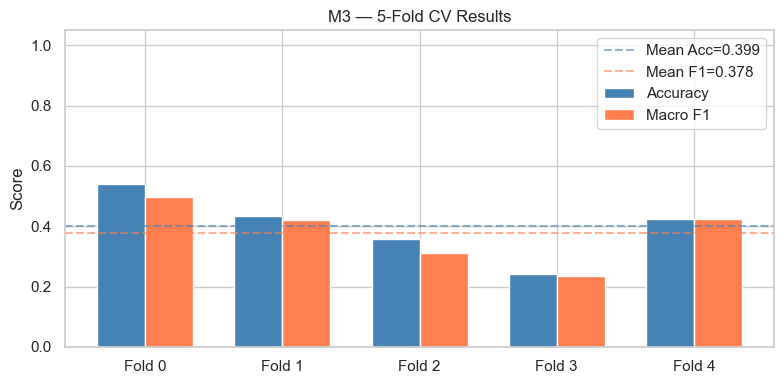

In [46]:

# ── Per-fold results ──────────────────────────────────────────────────────────
plot_fold_results(results)
plt.savefig(ROOT / 'results/reports/M3_fold_results.png', dpi=150, bbox_inches='tight')
plt.show()


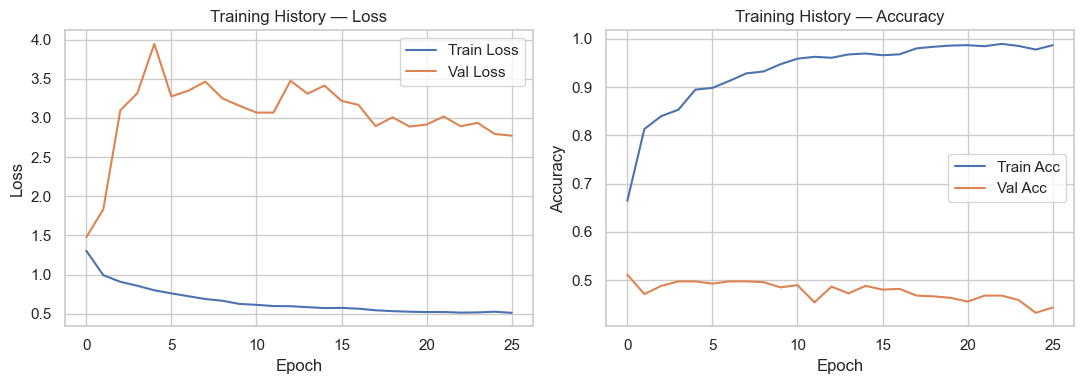

In [47]:
# ── Training history — Fold 0 ─────────────────────────────────────────────────
hist_fold0 = results['folds'][0].get('history')
if hist_fold0:
    plot_training_history(hist_fold0)
    plt.savefig(ROOT / 'results/reports/M3_history_fold0.png', dpi=150)
    plt.show()

In [49]:
# ── Confusion matrix (aggregate) ──────────────────────────────────────────────
all_true, all_pred = [], []
for fold in results['folds']:
    if 'y_true' in fold and 'y_pred' in fold:
        all_true.extend(fold['y_true'])
        all_pred.extend(fold['y_pred'])

if all_true:
    plot_confusion_matrix(np.array(all_true), np.array(all_pred),
                          class_names=CLASS_NAMES, title='M3 — Confusion Matrix (all folds)')
    plt.savefig(ROOT / 'results/reports/M3_confusion_matrix.png', dpi=150)
    plt.show()

TypeError: plot_confusion_matrix() got an unexpected keyword argument 'class_names'

In [50]:
# ── Attention weight analysis (Fold 0 best model) ─────────────────────────────
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from models.architecture import CrossModalAttentionBlock, M3FusionModel
from utils.helpers import plot_attention_weights
from data.load_data import load_fold

_model_name = 'M3'
_fold_idx   = 0

# Find the valid checkpoint (largest file wins)
_candidates = [
    ROOT / 'notebooks' / 'models' / 'checkpoints' / f'{_model_name}_fold{_fold_idx}.keras',
    ROOT / 'models'    / 'checkpoints'             / f'{_model_name}_fold{_fold_idx}.keras',
]
_valid = [p for p in _candidates if p.exists() and p.stat().st_size > 10_000]
print('Candidate checkpoints:')
for p in _candidates:
    size = p.stat().st_size if p.exists() else 0
    print(f'  {"✓" if p in _valid else "✗"}  {p}  ({size:,} bytes)')

if not _valid:
    print('\nNo valid checkpoint found. Run cell 4 (5-fold CV) first.')
else:
    ckpt_path = _valid[0]
    print(f'\nLoading: {ckpt_path}')

    m3_loaded = tf.keras.models.load_model(
        str(ckpt_path),
        custom_objects={'CrossModalAttentionBlock': CrossModalAttentionBlock,
                        'M3FusionModel': M3FusionModel}
    )

    fold0 = load_fold(str(FOLD_DIR), fold_idx=0)
    fau_sample  = fold0['mm_fau_test'][[0]].astype(np.float32)   # (1, 240, 30)
    tele_sample = fold0['mm_tele_test'][[0]].astype(np.float32)  # (1, 240,  5)

    H_fau_m  = m3_loaded.fau_bilstm(fau_sample,  training=False)
    H_tele_m = m3_loaded.tele_lstm (tele_sample, training=False)

    _, attn_f2t = m3_loaded.attn_f2t(H_fau_m,  H_tele_m, training=False)
    _, attn_t2f = m3_loaded.attn_t2f(H_tele_m, H_fau_m,  training=False)

    # shapes: (1, 240, 240) — pass full batch tensor, plot_attention_weights
    # slices [sample_idx] internally
    print('FAU→Tele attention shape :', attn_f2t.shape)
    print('Tele→FAU attention shape :', attn_t2f.shape)

    plot_attention_weights(attn_f2t.numpy(), attn_t2f.numpy(), sample_idx=0)
    plt.savefig(ROOT / 'results/reports/M3_attention_weights.png', dpi=150)
    plt.show()
    print('Saved → results/reports/M3_attention_weights.png')


Candidate checkpoints:
  ✓  C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\notebooks\models\checkpoints\M3_fold0.keras  (3,791,744 bytes)
  ✗  C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\models\checkpoints\M3_fold0.keras  (0 bytes)

Loading: C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\notebooks\models\checkpoints\M3_fold0.keras


TypeError: Could not locate function 'smooth_sparse_cce_0.1'. Make sure custom classes and functions are decorated with `@keras.saving.register_keras_serializable()`. If they are already decorated, make sure they are all imported so that the decorator is run before trying to load them. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'smooth_sparse_cce_0.1', 'registered_name': 'function'}

In [51]:
# ── Per-fold table ────────────────────────────────────────────────────────────
rows = [{'Fold': i, 'Accuracy': f.get('accuracy', float('nan')),
         'Macro-F1': f.get('macro_f1', float('nan'))}
        for i, f in enumerate(results['folds'])]
df = pd.DataFrame(rows)
df.loc['Mean'] = df.mean(numeric_only=True)
df.loc['Std']  = df.std(numeric_only=True)
df.style.format({'Accuracy': '{:.4f}', 'Macro-F1': '{:.4f}'})

,Fold,Accuracy,Macro-F1
0,0.000000,0.5398,0.4987
1,1.000000,0.4334,0.4212
2,2.000000,0.3587,0.3124
3,3.000000,0.2405,0.2336
4,4.000000,0.4238,0.4231
Mean,2.000000,0.3992,0.3778
Std,1.414214,0.0984,0.0934


In [52]:

# ── Save results to JSON for notebook 10 ─────────────────────────────────────
import json, numpy as np

def _to_serializable(obj):
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, dict):           return {k: _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):           return [_to_serializable(i) for i in obj]
    return obj

save_path = ROOT / 'results' / 'reports' / f'{MODEL_NAME}_results.json'
with open(save_path, 'w') as f:
    json.dump(_to_serializable(results), f, indent=2)
print(f'Saved → {save_path}')


Saved → C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\results\reports\M3_results.json
